# 🦟 Análise de Séries Temporais – Arboviroses em Serra/ES
## Projeto Integrador III – Ciência de Dados · FAESA
**Integrantes:** Emanoel Vitor · Luis Felipe · Natalia Pianca · Alessandro Girondoli · Rogeres José  
**Doenças:** Dengue (A90) · Zika (A928) · Chikungunya (A920)  
**Período:** 2015–2023 · **Município:** Serra/ES (IBGE: 3205069)  

---
> **Nota sobre os dados:** Este notebook tenta carregar os microdados reais do SINAN via `pysus`.  
> Caso o download falhe (sem internet, servidor indisponível etc.), o notebook entra automaticamente  
> em modo de **dados simulados** e avisa claramente em cada célula e gráfico.

---
## Seção 0 · Instalação de dependências

In [166]:
# Instale as dependências necessárias (execute uma vez)
# !pip install pysus pandas numpy matplotlib plotly statsmodels scipy --quiet

---
## Seção 1 · Imports e configuração global

In [167]:
import numpy as np
import pandas as pd
from collections import defaultdict
import math
import json
import re
import unicodedata
import urllib.request
import zipfile
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px
import folium
from pathlib import Path
from difflib import get_close_matches
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Constantes do projeto ────────────────────────────────────────────────────
CODIGO_IBGE_SERRA = '320506'   # código usado no SINAN (6 dígitos sem dígito verificador)
ANOS = list(range(2015, 2024))
CORES = {'Dengue': '#E63946', 'Zika': '#457B9D', 'Chikungunya': '#2A9D8F'}
NOMES_MES = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

USANDO_DADOS_REAIS = False  # será atualizado na Seção 2
print('✅ Imports OK')

✅ Imports OK


---
## Seção 2 · Carregamento dos dados reais (SINAN/DATASUS via pysus)

O notebook tenta baixar automaticamente os microdados do SINAN.  
Se falhar, cai no modo simulado e exibe um aviso claro.

In [168]:
URL_BAIRROS_IBGE = (
    'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/'
    'malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022/'
    'bairros/shp/UF/ES_bairros_CD2022.zip'
)
CODIGO_MUN_IBGE_SERRA = '3205002'
PASTA_BAIRROS_IBGE_REL = Path('data') / 'geografia' / 'bairros_ibge'

print('Fonte geográfica dos bairros configurada: IBGE Censo 2022')
print(f'URL: {URL_BAIRROS_IBGE}')
print(f'Pasta relativa do projeto: {PASTA_BAIRROS_IBGE_REL.as_posix()}')
print(f'Filtro municipal usado para Serra/ES: CD_MUN == {CODIGO_MUN_IBGE_SERRA}')


Fonte geográfica dos bairros configurada: IBGE Censo 2022
URL: https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022/bairros/shp/UF/ES_bairros_CD2022.zip
Pasta relativa do projeto: data/geografia/bairros_ibge
Filtro municipal usado para Serra/ES: CD_MUN == 3205002


In [169]:
def baixar_infodengue(geocode, doenca_code, label, anos):
    """
    Baixa dados semanais do InfoDengue (Fiocruz) e agrega por mês.
    geocode: código IBGE do município (Serra/ES = 3205002)
    doenca_code: 'dengue', 'zika', 'chikungunya'
    """
    import urllib.request, json

    print(f'  ⬇️  Baixando {label}...')
    base = 'https://info.dengue.mat.br/api/alertcity'

    partes = []
    for ano in anos:
        url = (f'{base}?geocode={geocode}'
               f'&disease={doenca_code}'
               f'&format=json'
               f'&ew_start=1'
               f'&ew_end=53'
               f'&ey_start={ano}'
               f'&ey_end={ano}')
        try:
            with urllib.request.urlopen(url, timeout=30) as r:
                dados = json.loads(r.read().decode())
            if dados:
                partes.extend(dados)
                print(f'     ✅ {label} {ano}: {len(dados)} semanas')
            else:
                print(f'     ⚠️  {label} {ano}: sem dados')
        except Exception as ex:
            print(f'     ⚠️  {label} {ano}: {ex}')

    if not partes:
        raise RuntimeError(f'Nenhum dado obtido para {label}')

    df = pd.DataFrame(partes)

    # data_iniSE vem em milissegundos — converte corretamente
    df['data'] = pd.to_datetime(df['data_iniSE'], unit='ms')
    df['ano']  = df['data'].dt.year
    df['mes']  = df['data'].dt.month
    df['doenca'] = label

    # Agrega casos por mês (soma das semanas epidemiológicas do mês)
    mensal = (df.groupby(['ano', 'mes', 'doenca'])['casos']
                .sum()
                .reset_index())
    mensal['casos'] = mensal['casos'].fillna(0).astype(int)

    print(f'     ✅ {label}: {len(mensal)} meses | {df["data"].min().date()} → {df["data"].max().date()}')
    return mensal


def gerar_dados_simulados():
    """Fallback: gera série mensal realista para fins didáticos."""
    np.random.seed(42)
    idx = pd.date_range('2015-01', periods=9*12, freq='MS')

    def serie(base, amp, trend, ruido, pico=2):
        t = np.arange(len(idx))
        s = base + trend*t + amp*np.sin(2*np.pi*(t-pico)/12) + np.random.normal(0, ruido, len(t))
        return np.maximum(0, s).astype(int)

    frames = []
    for doenca, (base, amp, trend, ruido, pico) in {
        'Dengue':      (300, 250, 1.8, 40, 2),
        'Zika':        (60,  80,  0.3, 15, 2),
        'Chikungunya': (80,  100, 0.9, 20, 3),
    }.items():
        casos = serie(base, amp, trend, ruido, pico)
        for i, dt in enumerate(idx):
            frames.append({'data': dt, 'ano': dt.year, 'mes': dt.month,
                           'doenca': doenca, 'casos': casos[i]})
    return pd.DataFrame(frames)


# ── Tentativa de download real via InfoDengue ────────────────────────────────
GEOCODE_SERRA = 3205002  # Serra/ES — código IBGE correto

try:
    print('🔄 Tentando baixar dados reais do InfoDengue (Fiocruz)...')
    mapa = [
        ('dengue',        'Dengue'),
        ('zika',          'Zika'),
        ('chikungunya',   'Chikungunya'),
    ]
    partes = []
    for code, label in mapa:
        partes.append(baixar_infodengue(GEOCODE_SERRA, code, label, ANOS))

    df_casos = pd.concat(partes, ignore_index=True)

    # Preenche meses sem casos com zero (série contínua)
    idx_completo = pd.date_range('2015-01', '2023-12', freq='MS')
    linhas = []
    for doenca in ['Dengue', 'Zika', 'Chikungunya']:
        for dt in idx_completo:
            sub = df_casos[(df_casos['doenca']==doenca) &
                           (df_casos['ano']==dt.year) &
                           (df_casos['mes']==dt.month)]
            casos = int(sub['casos'].sum()) if len(sub) else 0
            linhas.append({'data': dt, 'ano': dt.year, 'mes': dt.month,
                           'doenca': doenca, 'casos': casos})

    df_casos = pd.DataFrame(linhas)
    df_casos['data'] = pd.to_datetime(df_casos['data'])

    USANDO_DADOS_REAIS = True
    SUFIXO_TITULO = '<br><sup>Fonte: InfoDengue/Fiocruz – Serra/ES</sup>'
    AVISO_TITULO  = '\nFonte: InfoDengue/Fiocruz'
    print(f'\n✅ DADOS REAIS carregados com sucesso! {len(df_casos)} registros mensais.')

except Exception as e:
    print(f'\n⚠️  Falha no download: {e}')
    print('   → Modo DADOS SIMULADOS ativado (para fins didáticos)')
    df_casos = gerar_dados_simulados()
    USANDO_DADOS_REAIS = False
    SUFIXO_TITULO = '<br><sup>⚠️ DADOS SIMULADOS – substitua pelos dados reais do SINAN</sup>'
    AVISO_TITULO  = '\n⚠️ DADOS SIMULADOS'

print(f'\nDataset: {len(df_casos)} linhas | {df_casos["data"].min().date()} → {df_casos["data"].max().date()}')
print(f'Dados reais: {USANDO_DADOS_REAIS}')
df_casos.head(6)

🔄 Tentando baixar dados reais do InfoDengue (Fiocruz)...
  ⬇️  Baixando Dengue...
     ✅ Dengue 2015: 52 semanas
     ✅ Dengue 2016: 52 semanas
     ✅ Dengue 2017: 52 semanas
     ✅ Dengue 2018: 52 semanas
     ✅ Dengue 2019: 52 semanas
     ✅ Dengue 2020: 53 semanas
     ✅ Dengue 2021: 52 semanas
     ✅ Dengue 2022: 52 semanas
     ✅ Dengue 2023: 52 semanas
     ✅ Dengue: 108 meses | 2015-01-04 → 2023-12-24
  ⬇️  Baixando Zika...
     ✅ Zika 2015: 52 semanas
     ✅ Zika 2016: 52 semanas
     ✅ Zika 2017: 52 semanas
     ✅ Zika 2018: 52 semanas
     ✅ Zika 2019: 52 semanas
     ✅ Zika 2020: 53 semanas
     ✅ Zika 2021: 52 semanas
     ✅ Zika 2022: 52 semanas
     ✅ Zika 2023: 52 semanas
     ✅ Zika: 108 meses | 2015-01-04 → 2023-12-24
  ⬇️  Baixando Chikungunya...
     ✅ Chikungunya 2015: 52 semanas
     ✅ Chikungunya 2016: 52 semanas
     ✅ Chikungunya 2017: 52 semanas
     ✅ Chikungunya 2018: 52 semanas
     ✅ Chikungunya 2019: 52 semanas
     ✅ Chikungunya 2020: 53 semanas
     ✅ Ch

,data,ano,mes,doenca,casos
0,2015-01-01,2015,1,Dengue,174
1,2015-02-01,2015,2,Dengue,115
2,2015-03-01,2015,3,Dengue,279
3,2015-04-01,2015,4,Dengue,425
4,2015-05-01,2015,5,Dengue,779
5,2015-06-01,2015,6,Dengue,498


---
## Seção 3 · Estatísticas descritivas

In [170]:
resumo = (df_casos.groupby('doenca')['casos']
          .agg(total='sum', media_mensal='mean', mediana='median',
               maximo='max', desvio_padrao='std')
          .round(1))

fonte = 'SINAN/DATASUS (dados reais)' if USANDO_DADOS_REAIS else 'DADOS SIMULADOS'
print(f'Fonte: {fonte}')
print(f'Período: 2015–2023 | Município: Serra/ES\n')
print(resumo.to_string())

Fonte: SINAN/DATASUS (dados reais)
Período: 2015–2023 | Município: Serra/ES

             total  media_mensal  mediana  maximo  desvio_padrao
doenca                                                          
Chikungunya   1092          10.1      4.0      95           17.8
Dengue       60067         556.2    124.5    5659         1029.9
Zika           608           5.6      1.0      66           11.1


---
## Seção 4 · Séries temporais brutas (Plotly interativo)

In [171]:
fig = go.Figure()
for doenca, cor in CORES.items():
    d = df_casos[df_casos['doenca'] == doenca].sort_values('data')
    fig.add_trace(go.Scatter(
        x=d['data'], y=d['casos'],
        mode='lines', name=doenca,
        line=dict(color=cor, width=2),
        hovertemplate='%{x|%b/%Y}<br>Casos: %{y}<extra>' + doenca + '</extra>'
    ))

fig.update_layout(
    title='Notificações mensais de arboviroses – Serra/ES (2015–2023)' + SUFIXO_TITULO,
    xaxis_title='Mês', yaxis_title='Casos notificados',
    hovermode='x unified', template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=450
)
fig.show()

---
## Seção 5 · Decomposição das séries temporais (statsmodels)

A decomposição clássica separa cada série em três componentes:
- **Tendência** – direção geral ao longo dos anos
- **Sazonalidade** – padrão que se repete anualmente
- **Resíduo** – variação não explicada pelos dois anteriores

Usamos o modelo **aditivo** (`model='additive'`), adequado quando a amplitude sazonal não cresce proporcionalmente à tendência.

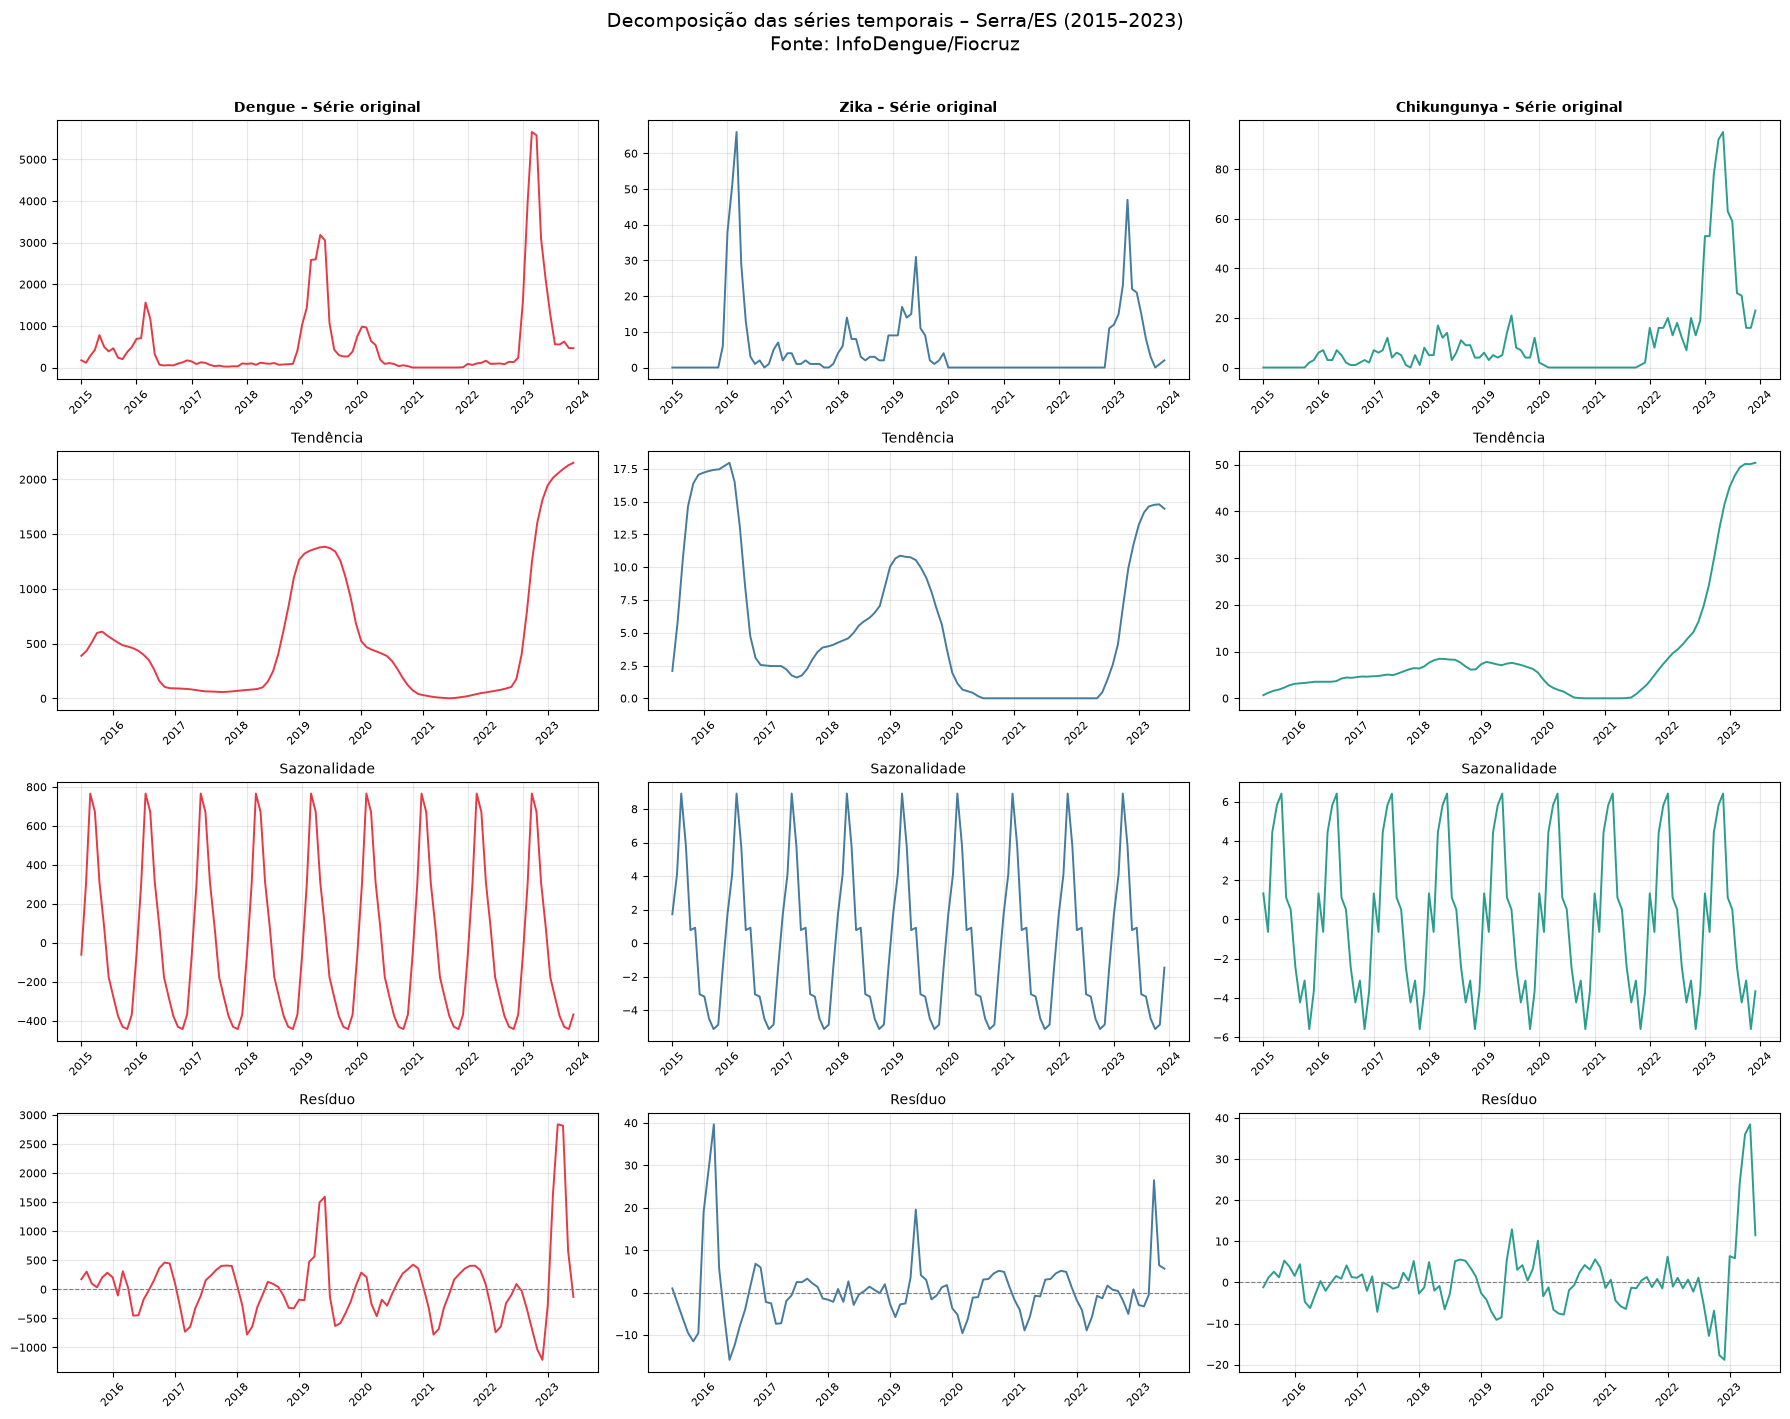

✅ Figura salva: decomposicao_series.png


In [172]:
doenças = ['Dengue', 'Zika', 'Chikungunya']
decomposições = {}

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 14))
suptitle = f'Decomposição das séries temporais – Serra/ES (2015–2023){AVISO_TITULO}'
fig.suptitle(suptitle, fontsize=14, y=1.01)

titulos_linhas = ['Série original', 'Tendência', 'Sazonalidade', 'Resíduo']
cores_mpl = {'Dengue': '#E63946', 'Zika': '#457B9D', 'Chikungunya': '#2A9D8F'}

for col, doenca in enumerate(doenças):
    serie = (df_casos[df_casos['doenca'] == doenca]
             .sort_values('data')
             .set_index('data')['casos']
             .asfreq('MS'))

    dec = seasonal_decompose(serie, model='additive', period=12)
    decomposições[doenca] = dec
    cor = cores_mpl[doenca]

    componentes = [serie, dec.trend, dec.seasonal, dec.resid]
    for row, (comp, titulo) in enumerate(zip(componentes, titulos_linhas)):
        ax = axes[row, col]
        ax.plot(comp.index, comp.values, color=cor, linewidth=1.4)
        ax.set_title(f'{doenca} – {titulo}' if row == 0 else titulo,
                     fontsize=10, fontweight='bold' if row == 0 else 'normal')
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        ax.grid(True, alpha=0.3)
        if row == 3:
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('decomposicao_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: decomposicao_series.png')

---
## Seção 6 · Padrão sazonal médio por mês

In [173]:
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=[f'<b>{d}</b>' for d in doenças],
                    shared_yaxes=False)

for col, doenca in enumerate(doenças, start=1):
    media_mes = (df_casos[df_casos['doenca'] == doenca]
                 .groupby('mes')['casos'].mean().round(1))
    cor = CORES[doenca]
    fig.add_trace(
        go.Bar(x=NOMES_MES, y=media_mes.values,
               name=doenca, marker_color=cor,
               hovertemplate='%{x}: %{y:.0f} casos/mês<extra></extra>',
               showlegend=False),
        row=1, col=col
    )
    pico = media_mes.idxmax()
    fig.add_annotation(
        x=NOMES_MES[pico - 1], y=media_mes[pico],
        text=f'Pico: {NOMES_MES[pico-1]}', showarrow=True,
        arrowhead=2, ax=0, ay=-30, font=dict(size=10, color=cor),
        xref=f'x{col}', yref=f'y{col}'
    )

fig.update_layout(
    title='Média de casos por mês (2015–2023) – sazonalidade histórica' + SUFIXO_TITULO,
    template='plotly_white', height=420,
    yaxis_title='Média de casos'
)
fig.show()

---
## Seção 7 · Evolução anual de casos (tendência)

In [174]:
anual = df_casos.groupby(['ano', 'doenca'])['casos'].sum().reset_index()

fig = px.line(anual, x='ano', y='casos', color='doenca',
              markers=True,
              color_discrete_map=CORES,
              labels={'ano': 'Ano', 'casos': 'Total de casos', 'doenca': 'Doença'},
              title='Total anual de casos notificados – Serra/ES (2015–2023)' + SUFIXO_TITULO)
fig.update_traces(line_width=2.5, marker_size=8)
fig.update_layout(template='plotly_white', height=420, hovermode='x unified')
fig.show()

---
## Seção 8 · Heatmap de sazonalidade (ano × mês)

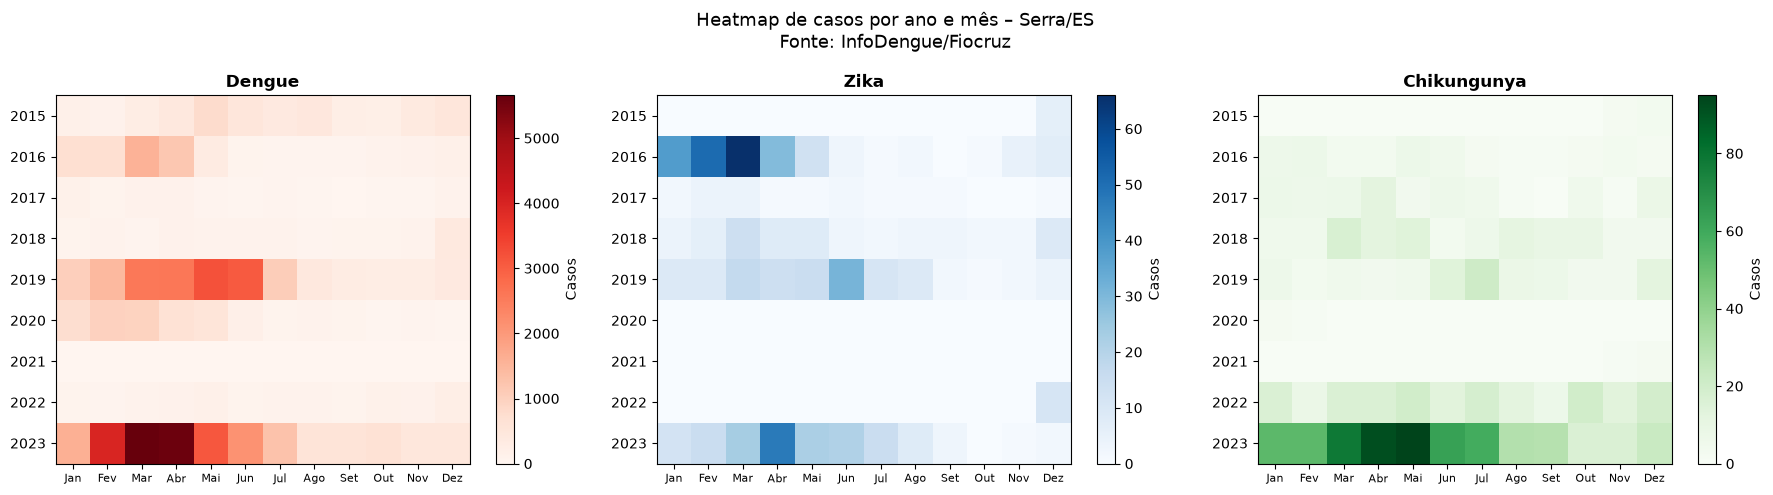

✅ Figura salva: heatmap_sazonalidade.png


In [175]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Heatmap de casos por ano e mês – Serra/ES{AVISO_TITULO}', fontsize=13)

for ax, doenca in zip(axes, doenças):
    pivot = (df_casos[df_casos['doenca'] == doenca]
             .pivot_table(index='ano', columns='mes', values='casos', aggfunc='sum'))
    pivot.columns = NOMES_MES[:len(pivot.columns)]

    cmap = {'Dengue': 'Reds', 'Zika': 'Blues', 'Chikungunya': 'Greens'}[doenca]
    im = ax.imshow(pivot.values, aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=8)
    ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
    ax.set_title(doenca, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Casos')

plt.tight_layout()
plt.savefig('heatmap_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: heatmap_sazonalidade.png')

---
## Seção 9 · Componente sazonal extraído pela decomposição

In [176]:
fig = go.Figure()
for doenca in doenças:
    sazonal_ciclo = decomposições[doenca].seasonal.iloc[:12]
    fig.add_trace(go.Scatter(
        x=NOMES_MES,
        y=sazonal_ciclo.values,
        mode='lines+markers',
        name=doenca,
        line=dict(color=CORES[doenca], width=2.5),
        marker=dict(size=8)
    ))

fig.add_hline(y=0, line_dash='dash', line_color='gray', line_width=1)
fig.update_layout(
    title='Componente sazonal extraído (statsmodels) – 1 ciclo anual' + SUFIXO_TITULO,
    xaxis_title='Mês', yaxis_title='Efeito sazonal (casos)',
    template='plotly_white', height=420,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.show()

---
## Seção 10 · Conclusões – Séries Temporais

> **Se estiver usando dados reais:** atualize as conclusões abaixo com os valores reais observados.

In [177]:
print('=' * 65)
print('CONCLUSÕES – SÉRIES TEMPORAIS · Serra/ES (2015–2023)')
print('=' * 65)
for doenca in doenças:
    total = df_casos[df_casos['doenca']==doenca]['casos'].sum()
    media = df_casos[df_casos['doenca']==doenca]['casos'].mean()
    pico_mes = (df_casos[df_casos['doenca']==doenca]
                .groupby('mes')['casos'].mean().idxmax())
    trend = decomposições[doenca].trend.dropna()
    variacao_trend = trend.iloc[-1] - trend.iloc[0]
    direcao = '↑ crescente' if variacao_trend > 0 else '↓ decrescente'
    print(f'\n{doenca}:')
    print(f'  Total no período : {total:,} casos')
    print(f'  Média mensal     : {media:.1f} casos/mês')
    print(f'  Mês de pico      : {NOMES_MES[pico_mes-1]}')
    print(f'  Tendência        : {direcao} ({variacao_trend:+.0f} casos entre início e fim da tendência)')
print(f'\nFonte: {"SINAN/DATASUS – dados reais" if USANDO_DADOS_REAIS else "⚠️ DADOS SIMULADOS"}')

CONCLUSÕES – SÉRIES TEMPORAIS · Serra/ES (2015–2023)

Dengue:
  Total no período : 60,067 casos
  Média mensal     : 556.2 casos/mês
  Mês de pico      : Mar
  Tendência        : ↑ crescente (+1762 casos entre início e fim da tendência)

Zika:
  Total no período : 608 casos
  Média mensal     : 5.6 casos/mês
  Mês de pico      : Mar
  Tendência        : ↑ crescente (+12 casos entre início e fim da tendência)

Chikungunya:
  Total no período : 1,092 casos
  Média mensal     : 10.1 casos/mês
  Mês de pico      : Mai
  Tendência        : ↑ crescente (+50 casos entre início e fim da tendência)

Fonte: SINAN/DATASUS – dados reais


---
## 🌧️ Correlação Climática

### Seção 11 · Geração dos dados climáticos (INMET)

Fonte ideal: [INMET – Banco de Dados Meteorológicos](https://bdmep.inmet.gov.br/)  
Estação mais próxima de Serra/ES: **Vitória (A612)**  

**Para usar dados reais do INMET:**  
1. Acesse https://bdmep.inmet.gov.br  
2. Selecione a estação **A612 – Vitória/ES**  
3. Período: 01/01/2015 a 31/12/2023  
4. Variáveis: Precipitação Total e Temperatura Média  
5. Salve como CSV e substitua o DataFrame `df_clima` abaixo

In [178]:
# ── Tentativa de leitura de dados reais do INMET (CSV exportado) ─────────────
# Se você tiver o arquivo, descomente e ajuste o caminho:
# import os
# if os.path.exists('inmet_vitoria_2015_2023.csv'):
#     df_inmet = pd.read_csv('inmet_vitoria_2015_2023.csv', sep=';', encoding='latin1')
#     # ajuste os nomes das colunas conforme o arquivo real
#     df_inmet['data'] = pd.to_datetime(df_inmet['Data'], dayfirst=True)
#     df_clima = (df_inmet.groupby([df_inmet['data'].dt.year.rename('ano'),
#                                   df_inmet['data'].dt.month.rename('mes')])
#                 .agg(precip_mm=('Precipitacao Total (mm)', 'sum'),
#                      temp_c=('Temperatura Media (C)', 'mean'))
#                 .reset_index())
#     CLIMA_REAL = True
# else:

# ── Dados climáticos simulados (sazonalidade realista para Vitória/ES) ───────
np.random.seed(7)
idx_clima = pd.date_range('2015-01', periods=9*12, freq='MS')
t = np.arange(len(idx_clima))

# Vitória: chuvas concentradas em nov–mar, seco em jun–ago
precip = (180 + 150*np.sin(2*np.pi*(t - 1)/12) +
          np.random.normal(0, 30, len(t))).clip(0)
temp   = (24  + 4  *np.sin(2*np.pi*(t - 1)/12) +
          np.random.normal(0, 0.5, len(t)))

df_clima = pd.DataFrame({
    'data':      idx_clima,
    'ano':       idx_clima.year,
    'mes':       idx_clima.month,
    'precip_mm': precip.round(1),
    'temp_c':    temp.round(1),
})
CLIMA_REAL = False
print(f'Dados climáticos: {"reais" if CLIMA_REAL else "simulados (substitua pelo CSV do INMET)"}')
df_clima.head()

Dados climáticos: simulados (substitua pelo CSV do INMET)


,data,ano,mes,precip_mm,temp_c
0,2015-01-01,2015,1,155.7,22.9
1,2015-02-01,2015,2,166.0,23.8
2,2015-03-01,2015,3,256.0,25.9
3,2015-04-01,2015,4,322.1,27.6
4,2015-05-01,2015,5,306.3,28.5


### Seção 12 · Visualização das séries climáticas

In [179]:
aviso_clima = '' if CLIMA_REAL else '<br><sup>⚠️ Dados climáticos simulados</sup>'

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Precipitação mensal (mm)', 'Temperatura média (°C)'],
                    vertical_spacing=0.08)

fig.add_trace(go.Bar(x=df_clima['data'], y=df_clima['precip_mm'],
                     name='Precipitação', marker_color='#4CC9F0',
                     hovertemplate='%{x|%b/%Y}: %{y:.0f} mm<extra></extra>'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_clima['data'], y=df_clima['temp_c'],
                          name='Temperatura', line=dict(color='#F77F00', width=2),
                          hovertemplate='%{x|%b/%Y}: %{y:.1f}°C<extra></extra>'), row=2, col=1)

fig.update_layout(title='Variáveis climáticas – Vitória/ES (estação INMET A612)' + aviso_clima,
                  template='plotly_white', height=500, showlegend=False)
fig.show()

### Seção 13 · Correlação temporal com precipitação e temperatura (Pearson / Spearman)

In [180]:
# Merge casos × clima por ano e mês
doenças_lista = ['Dengue', 'Zika', 'Chikungunya']
df_pivot = (df_casos.pivot_table(index=['ano','mes'], columns='doenca',
                                  values='casos', aggfunc='sum')
            .reset_index())
df_corr = df_pivot.merge(df_clima[['ano','mes','precip_mm','temp_c']], on=['ano','mes'])

# ── Matrizes de correlação ───────────────────────────────────────────────────
vars_clima = ['precip_mm', 'temp_c']
labels_clima = ['Precip. (mm)', 'Temp. (°C)']

pearson_matrix  = np.zeros((len(doenças_lista), len(vars_clima)))
spearman_matrix = np.zeros((len(doenças_lista), len(vars_clima)))

print('=' * 60)
print('CORRELAÇÕES · Casos de arboviroses × Clima (2015–2023)')
print('=' * 60)
for i, doenca in enumerate(doenças_lista):
    for j, var in enumerate(vars_clima):
        x = df_corr[doenca].values
        y = df_corr[var].values
        r_p, p_p = stats.pearsonr(x, y)
        r_s, p_s = stats.spearmanr(x, y)
        pearson_matrix[i, j]  = r_p
        spearman_matrix[i, j] = r_s
        sig_p = '***' if p_p < 0.001 else '**' if p_p < 0.01 else '*' if p_p < 0.05 else 'ns'
        sig_s = '***' if p_s < 0.001 else '**' if p_s < 0.01 else '*' if p_s < 0.05 else 'ns'
        print(f'{doenca:14s} × {labels_clima[j]:14s} | '
              f'Pearson r={r_p:+.3f}{sig_p:3s} | Spearman ρ={r_s:+.3f}{sig_s}')
print('\n(*** p<0.001  ** p<0.01  * p<0.05  ns = não significativo)')

CORRELAÇÕES · Casos de arboviroses × Clima (2015–2023)
Dengue         × Precip. (mm)   | Pearson r=+0.281**  | Spearman ρ=+0.185ns
Dengue         × Temp. (°C)     | Pearson r=+0.309**  | Spearman ρ=+0.177ns
Zika           × Precip. (mm)   | Pearson r=+0.220*   | Spearman ρ=+0.151ns
Zika           × Temp. (°C)     | Pearson r=+0.234*   | Spearman ρ=+0.138ns
Chikungunya    × Precip. (mm)   | Pearson r=+0.183ns  | Spearman ρ=+0.044ns
Chikungunya    × Temp. (°C)     | Pearson r=+0.181ns  | Spearman ρ=+0.018ns

(*** p<0.001  ** p<0.01  * p<0.05  ns = não significativo)


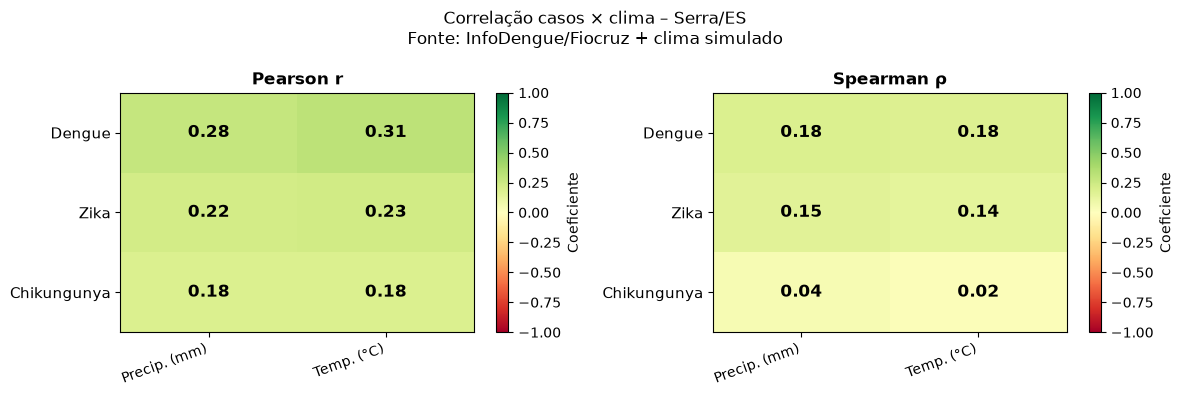

✅ Figura salva: correlacao_climatica.png


In [181]:
# ── Heatmap das correlações ──────────────────────────────────────────────────
aviso_mpl = AVISO_TITULO + (' + clima simulado' if not CLIMA_REAL else '')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Correlação casos × clima – Serra/ES{aviso_mpl}', fontsize=12)

n_d = len(doenças_lista)
n_v = len(vars_clima)

for ax, matrix, titulo in zip(axes, [pearson_matrix, spearman_matrix], ['Pearson r', 'Spearman ρ']):
    im = ax.imshow(matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_v));  ax.set_xticklabels(labels_clima, rotation=20, ha='right', fontsize=10)
    ax.set_yticks(range(n_d));  ax.set_yticklabels(doenças_lista, fontsize=11)
    ax.set_title(titulo, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Coeficiente')
    for i in range(n_d):
        for j in range(n_v):
            val = matrix[i, j]
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if abs(val) > 0.6 else 'black')

plt.tight_layout()
plt.savefig('correlacao_climatica.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: correlacao_climatica.png')

### Seção 14 · Dispersão: casos × variáveis climáticas

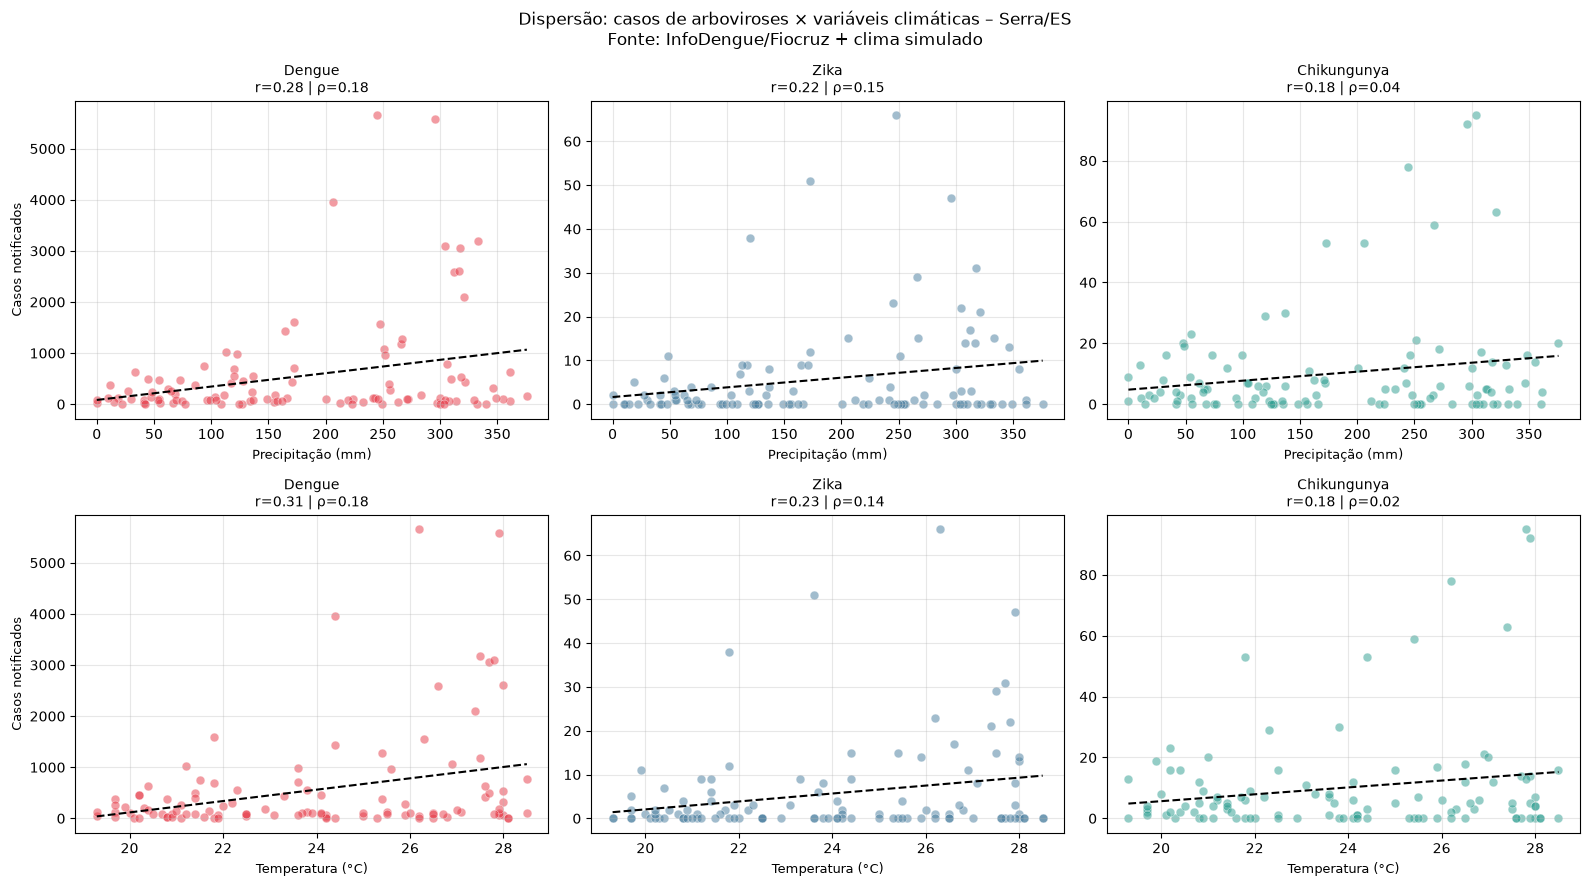

✅ Figura salva: dispersao_casos_clima.png


In [182]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Dispersão: casos de arboviroses × variáveis climáticas – Serra/ES{aviso_mpl}', fontsize=12)

cores_mpl = {'Dengue': '#E63946', 'Zika': '#457B9D', 'Chikungunya': '#2A9D8F'}

for col_idx, doenca in enumerate(doenças_lista):
    cor = cores_mpl[doenca]
    x_casos = df_corr[doenca].values

    for row_idx, (var_col, var_label) in enumerate([('precip_mm', 'Precipitação (mm)'),
                                                    ('temp_c',    'Temperatura (°C)')]):
        ax = axes[row_idx, col_idx]
        y_clima = df_corr[var_col].values

        ax.scatter(y_clima, x_casos, alpha=0.5, color=cor, s=40,
                   edgecolors='white', linewidths=0.5)

        z = np.polyfit(y_clima, x_casos, 1)
        p = np.poly1d(z)
        x_line = np.linspace(y_clima.min(), y_clima.max(), 100)
        ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--')

        r_p, _ = stats.pearsonr(x_casos, y_clima)
        r_s, _ = stats.spearmanr(x_casos, y_clima)
        ax.set_title(f'{doenca}\nr={r_p:.2f} | ρ={r_s:.2f}', fontsize=10)
        ax.set_xlabel(var_label, fontsize=9)
        ax.set_ylabel('Casos notificados' if col_idx == 0 else '', fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dispersao_casos_clima.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva: dispersao_casos_clima.png')

### Seção 15 · Identificação dos meses de pico histórico

In [183]:
resultados_pico = []

for doenca in doenças_lista:
    df_d = df_casos[df_casos['doenca'] == doenca].copy()
    media_mes = df_d.groupby('mes')['casos'].mean()
    top3 = media_mes.nlargest(3)

    # Consistência: em quantos anos aquele mês foi o de maior volume?
    pico_por_ano = (df_d.groupby('ano')
                    .apply(lambda g: g.loc[g['casos'].idxmax(), 'mes'],
                           include_groups=False))
    consistencia = pico_por_ano.value_counts()

    for rank, (mes_num, media) in enumerate(top3.items(), start=1):
        resultados_pico.append({
            'Doença':          doenca,
            'Rank':            rank,
            'Mês':             NOMES_MES[mes_num - 1],
            'Nº do mês':       mes_num,
            'Média histórica': round(media, 1),
            'Anos como pico':  consistencia.get(mes_num, 0)
        })

df_picos = pd.DataFrame(resultados_pico)
print('=' * 60)
print('TOP-3 MESES DE PICO HISTÓRICO POR DOENÇA (2015–2023)')
print('=' * 60)
print(df_picos.to_string(index=False))

TOP-3 MESES DE PICO HISTÓRICO POR DOENÇA (2015–2023)
     Doença  Rank Mês  Nº do mês  Média histórica  Anos como pico
     Dengue     1 Mar          3           1259.4               2
     Dengue     2 Abr          4           1195.2               0
     Dengue     3 Mai          5            916.1               2
       Zika     1 Mar          3             13.8               2
       Zika     2 Abr          4             11.0               1
       Zika     3 Fev          2              9.4               1
Chikungunya     1 Mai          5             16.1               2
Chikungunya     2 Abr          4             15.4               1
Chikungunya     3 Mar          3             14.0               1


In [184]:
# ── Visualização dos picos ───────────────────────────────────────────────────
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=[f'<b>{d}</b>' for d in doenças_lista],
                    shared_yaxes=False)

for col_idx, doenca in enumerate(doenças_lista, start=1):
    df_d      = df_casos[df_casos['doenca'] == doenca]
    media_mes = df_d.groupby('mes')['casos'].mean().round(1)
    top3_idx  = media_mes.nlargest(3).index.tolist()
    cor_base  = CORES[doenca]

    bar_cores = ['#FF4444' if m in top3_idx[:1]
                 else '#FF9944' if m in top3_idx[1:2]
                 else '#FFCC44' if m in top3_idx[2:]
                 else cor_base
                 for m in media_mes.index]

    fig.add_trace(go.Bar(
        x=NOMES_MES, y=media_mes.values,
        marker_color=bar_cores, name=doenca,
        showlegend=False,
        hovertemplate='%{x}: %{y:.0f} casos/mês<extra></extra>'
    ), row=1, col=col_idx)

    pico_mes = media_mes.idxmax()
    pico_val = media_mes[pico_mes]
    fig.add_annotation(
        x=NOMES_MES[pico_mes - 1], y=pico_val,
        text=f' {NOMES_MES[pico_mes-1]}',
        showarrow=True, arrowhead=2, ax=0, ay=-35,
        font=dict(size=10, color='#CC0000', family='Arial Black'),
        xref=f'x{col_idx}', yref=f'y{col_idx}'
    )

# Legenda manual
for label, color in [('🥇 1º pico','#FF4444'),('🥈 2º pico','#FF9944'),('🥉 3º pico','#FFCC44')]:
    fig.add_trace(go.Bar(x=[None], y=[None], marker_color=color, name=label, showlegend=True))

fig.update_layout(
    title='Média histórica de casos por mês – picos destacados (2015–2023)' + SUFIXO_TITULO,
    template='plotly_white', height=430, barmode='group',
    legend=dict(orientation='h', y=1.08, x=0.5, xanchor='center')
)
fig.update_yaxes(title_text='Média de casos', row=1, col=1)
fig.show()

---
### Seção 16 · Conclusões - Correlação Climática e Picos Históricos

In [185]:
print('=' * 65)
print('CONCLUSÕES - CORRELAÇÃO CLIMÁTICA E PICOS HISTÓRICOS')
print('Serra/ES (2015–2023)')
print('=' * 65)

for i, doenca in enumerate(doenças_lista):
    rp_prec = pearson_matrix[i, 0]
    rs_prec = spearman_matrix[i, 0]
    rp_temp = pearson_matrix[i, 1]
    rs_temp = spearman_matrix[i, 1]
    top1 = df_picos[(df_picos['Doença']==doenca) & (df_picos['Rank']==1)].iloc[0]
    print(f'\n{doenca}:')
    print(f'  Corr. precipitação : Pearson r={rp_prec:+.2f} | Spearman ρ={rs_prec:+.2f}')
    print(f'  Corr. temperatura  : Pearson r={rp_temp:+.2f} | Spearman ρ={rs_temp:+.2f}')
    print(f'  Mês de pico        : {top1["Mês"]} (média histórica: {top1["Média histórica"]:.0f} casos/mês)')
    print(f'  Consistência pico  : {top1["Anos como pico"]} de 9 anos analisados')

print(f'\nFonte epidemiológica : {"SINAN/DATASUS – dados reais" if USANDO_DADOS_REAIS else "⚠️ Dados simulados"}')
print(f'Fonte climática      : {"INMET – dados reais" if CLIMA_REAL else "⚠️ Dados simulados"}')

CONCLUSÕES - CORRELAÇÃO CLIMÁTICA E PICOS HISTÓRICOS
Serra/ES (2015–2023)

Dengue:
  Corr. precipitação : Pearson r=+0.28 | Spearman ρ=+0.18
  Corr. temperatura  : Pearson r=+0.31 | Spearman ρ=+0.18
  Mês de pico        : Mar (média histórica: 1259 casos/mês)
  Consistência pico  : 2 de 9 anos analisados

Zika:
  Corr. precipitação : Pearson r=+0.22 | Spearman ρ=+0.15
  Corr. temperatura  : Pearson r=+0.23 | Spearman ρ=+0.14
  Mês de pico        : Mar (média histórica: 14 casos/mês)
  Consistência pico  : 2 de 9 anos analisados

Chikungunya:
  Corr. precipitação : Pearson r=+0.18 | Spearman ρ=+0.04
  Corr. temperatura  : Pearson r=+0.18 | Spearman ρ=+0.02
  Mês de pico        : Mai (média histórica: 16 casos/mês)
  Consistência pico  : 2 de 9 anos analisados

Fonte epidemiológica : SINAN/DATASUS – dados reais
Fonte climática      : ⚠️ Dados simulados


In [186]:
from pathlib import Path
import zipfile
import requests
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

if 'df_casos' not in globals():
    raise RuntimeError('Execute a Seção 2 antes desta etapa para carregarmos df_casos.')

colunas_df_casos_necessarias = ['data', 'ano', 'mes', 'doenca', 'casos']
colunas_ausentes_df_casos = [coluna for coluna in colunas_df_casos_necessarias if coluna not in df_casos.columns]
if colunas_ausentes_df_casos:
    raise KeyError(f'Colunas ausentes em df_casos: {colunas_ausentes_df_casos}')

if not bool(globals().get('USANDO_DADOS_REAIS', False)):
    raise RuntimeError('Esta seção deve ser executada após o carregamento real do InfoDengue/Fiocruz na Seção 2.')

df_casos_municipal = df_casos[colunas_df_casos_necessarias].copy()
df_casos_municipal['data'] = pd.to_datetime(df_casos_municipal['data'])
df_casos_municipal['ano'] = df_casos_municipal['ano'].astype(int)
df_casos_municipal['mes'] = df_casos_municipal['mes'].astype(int)
df_casos_municipal['casos'] = pd.to_numeric(df_casos_municipal['casos'], errors='coerce').fillna(0).astype(int)
fonte_casos_municipais = 'InfoDengue/Fiocruz - Serra/ES'
periodo_inicio_municipal = df_casos_municipal['data'].min()
periodo_fim_municipal = df_casos_municipal['data'].max()

URL_BAIRROS_IBGE = globals().get(
    'URL_BAIRROS_IBGE',
    'https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/'
    'malhas_de_setores_censitarios__divisoes_intramunicipais/censo_2022/'
    'bairros/shp/UF/ES_bairros_CD2022.zip'
)
CODIGO_MUN_IBGE_SERRA = globals().get('CODIGO_MUN_IBGE_SERRA', '3205002')
COLUNAS_BAIRROS_PRINCIPAIS = ['CD_MUN', 'NM_MUN', 'CD_BAIRRO', 'NM_BAIRRO', 'NM_DIST', 'geometry']


def encontrar_raiz_projeto():
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / 'requirements.txt').exists() and (candidato / 'data').exists():
            return candidato
    return atual


PROJETO_RAIZ = encontrar_raiz_projeto()
PASTA_BAIRROS_IBGE_REL = Path('data') / 'geografia' / 'bairros_ibge'
PASTA_BAIRROS_IBGE = PROJETO_RAIZ / PASTA_BAIRROS_IBGE_REL
ZIP_BAIRROS_IBGE = PASTA_BAIRROS_IBGE / 'ES_bairros_CD2022.zip'


def caminho_relativo(caminho):
    caminho = Path(caminho).resolve()
    try:
        return caminho.relative_to(PROJETO_RAIZ).as_posix()
    except ValueError:
        return caminho.as_posix()


def shapefile_completo(caminho_shp):
    return all(caminho_shp.with_suffix(ext).exists() for ext in ['.shp', '.shx', '.dbf', '.prj'])


def baixar_zip_ibge(url, destino):
    destino.parent.mkdir(parents=True, exist_ok=True)
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        with requests.get(url, headers=headers, stream=True, timeout=120) as resposta:
            resposta.raise_for_status()
            with destino.open('wb') as arquivo:
                for parte in resposta.iter_content(chunk_size=1024 * 1024):
                    if parte:
                        arquivo.write(parte)
    except Exception as exc:
        raise RuntimeError('Falha ao baixar o ZIP de bairros do IBGE.') from exc


if ZIP_BAIRROS_IBGE.exists() and ZIP_BAIRROS_IBGE.stat().st_size > 0:
    print(f'ZIP do IBGE encontrado em: {caminho_relativo(ZIP_BAIRROS_IBGE)}')
else:
    print('Baixando ZIP oficial dos bairros do IBGE...')
    baixar_zip_ibge(URL_BAIRROS_IBGE, ZIP_BAIRROS_IBGE)
    print(f'ZIP salvo em: {caminho_relativo(ZIP_BAIRROS_IBGE)}')

shapefiles = sorted(PASTA_BAIRROS_IBGE.rglob('*.shp')) if PASTA_BAIRROS_IBGE.exists() else []
SHP_PATH = next((caminho for caminho in shapefiles if caminho.name == 'ES_bairros_CD2022.shp' and shapefile_completo(caminho)), None)

if SHP_PATH is None:
    print('Extraindo arquivos do ZIP de bairros do IBGE...')
    PASTA_BAIRROS_IBGE.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_BAIRROS_IBGE, 'r') as arquivo_zip:
        arquivo_zip.extractall(PASTA_BAIRROS_IBGE)
    shapefiles = sorted(PASTA_BAIRROS_IBGE.rglob('*.shp'))
    SHP_PATH = next((caminho for caminho in shapefiles if shapefile_completo(caminho)), None)

if SHP_PATH is None:
    raise FileNotFoundError('Shapefile completo ausente após a extração do ZIP do IBGE.')

print(f'Shapefile carregado a partir de: {caminho_relativo(SHP_PATH)}')

gdf_bairros = gpd.read_file(SHP_PATH)
colunas_ausentes_bairros = [coluna for coluna in COLUNAS_BAIRROS_PRINCIPAIS if coluna not in gdf_bairros.columns]
if colunas_ausentes_bairros:
    raise KeyError(f'Colunas ausentes na malha de bairros: {colunas_ausentes_bairros}')

gdf_bairros['CD_MUN'] = gdf_bairros['CD_MUN'].astype(str)
gdf_bairros_serra = gdf_bairros[gdf_bairros['CD_MUN'].eq(CODIGO_MUN_IBGE_SERRA)].copy()
if gdf_bairros_serra.empty:
    raise ValueError(f'O filtro CD_MUN == {CODIGO_MUN_IBGE_SERRA} retornou zero bairros da Serra/ES.')

crs_original_bairros = gdf_bairros_serra.crs
if gdf_bairros_serra.crs is not None and gdf_bairros_serra.crs.to_epsg() != 4326:
    gdf_bairros_serra = gdf_bairros_serra.to_crs(epsg=4326)

gdf_bairros_serra = gdf_bairros_serra.reset_index(drop=True)
df_bairros_ibge = gdf_bairros_serra[COLUNAS_BAIRROS_PRINCIPAIS].copy()
df_bairros_reconhecidos = (
    df_bairros_ibge[['NM_BAIRRO', 'CD_BAIRRO', 'NM_DIST', 'NM_MUN']]
    .drop_duplicates('CD_BAIRRO')
    .sort_values('NM_BAIRRO')
    .reset_index(drop=True)
)

total_bairros_reconhecidos = len(df_bairros_reconhecidos)
total_casos_municipal_geral = int(df_casos_municipal['casos'].sum())
media_municipal_geral_por_bairro = total_casos_municipal_geral / total_bairros_reconhecidos

df_total_doenca_municipal = (
    df_casos_municipal
    .groupby('doenca', as_index=False)['casos']
    .sum()
    .sort_values('casos', ascending=False)
    .reset_index(drop=True)
)
df_total_doenca_municipal['participacao_percentual'] = df_total_doenca_municipal['casos'].div(total_casos_municipal_geral).mul(100)
df_total_doenca_municipal['media_municipal_por_bairro'] = df_total_doenca_municipal['casos'].div(total_bairros_reconhecidos)

df_total_ano_municipal = (
    df_casos_municipal
    .groupby('ano', as_index=False)['casos']
    .sum()
    .sort_values('ano')
    .reset_index(drop=True)
)
df_total_ano_municipal['media_municipal_por_bairro'] = df_total_ano_municipal['casos'].div(total_bairros_reconhecidos)

df_total_ano_doenca_municipal = (
    df_casos_municipal
    .groupby(['ano', 'doenca'], as_index=False)['casos']
    .sum()
    .sort_values(['ano', 'doenca'])
    .reset_index(drop=True)
)
df_total_ano_doenca_municipal['media_municipal_por_bairro'] = df_total_ano_doenca_municipal['casos'].div(total_bairros_reconhecidos)

df_anos_criticos_municipais = (
    df_total_ano_municipal
    .sort_values('casos', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

df_meses_criticos_municipais = (
    df_casos_municipal
    .groupby('data', as_index=False)['casos']
    .sum()
    .sort_values('casos', ascending=False)
    .head(5)
    .reset_index(drop=True)
)
df_meses_criticos_municipais['ano'] = df_meses_criticos_municipais['data'].dt.year
df_meses_criticos_municipais['mes'] = df_meses_criticos_municipais['data'].dt.month
df_meses_criticos_municipais['periodo'] = df_meses_criticos_municipais['data'].dt.strftime('%m/%Y')
df_meses_criticos_municipais['media_municipal_por_bairro'] = df_meses_criticos_municipais['casos'].div(total_bairros_reconhecidos)

df_picos_doenca_municipais = (
    df_casos_municipal
    .sort_values('casos', ascending=False)
    .groupby('doenca', as_index=False)
    .first()[['doenca', 'data', 'ano', 'mes', 'casos']]
    .sort_values('casos', ascending=False)
    .reset_index(drop=True)
)
df_picos_doenca_municipais['periodo'] = df_picos_doenca_municipais['data'].dt.strftime('%m/%Y')
df_picos_doenca_municipais['media_municipal_por_bairro'] = df_picos_doenca_municipais['casos'].div(total_bairros_reconhecidos)

df_resumo_geral_mapa_bairros = pd.DataFrame([{
    'periodo_inicio': periodo_inicio_municipal.date(),
    'periodo_fim': periodo_fim_municipal.date(),
    'total_bairros': total_bairros_reconhecidos,
    'total_casos_municipais': total_casos_municipal_geral,
    'media_municipal_por_bairro': media_municipal_geral_por_bairro,
    'fonte_casos': fonte_casos_municipais,
    'fonte_malha': 'IBGE/Censo 2022'
}])

print('Carregamento da parte de Mapa & Bairros concluído.')
print(f'Fonte dos casos municipais: {fonte_casos_municipais}')
print(f'Período dos casos municipais: {periodo_inicio_municipal.date()} a {periodo_fim_municipal.date()}')
print(f'Doenças analisadas: {sorted(df_casos_municipal["doenca"].unique())}')
print(f'Bairros reconhecidos na malha real do IBGE: {total_bairros_reconhecidos}')
print(f'Média municipal por bairro no período: {media_municipal_geral_por_bairro:.1f} casos')
print(f'CRS original da malha: {crs_original_bairros}')
print(f'CRS usado na visualização: {gdf_bairros_serra.crs}')


ZIP do IBGE encontrado em: data/geografia/bairros_ibge/ES_bairros_CD2022.zip
Shapefile carregado a partir de: data/geografia/bairros_ibge/ES_bairros_CD2022.shp
Carregamento da parte de Mapa & Bairros concluído.
Fonte dos casos municipais: InfoDengue/Fiocruz - Serra/ES
Período dos casos municipais: 2015-01-01 a 2023-12-01
Doenças analisadas: ['Chikungunya', 'Dengue', 'Zika']
Bairros reconhecidos na malha real do IBGE: 130
Média municipal por bairro no período: 475.1 casos
CRS original da malha: EPSG:4674
CRS usado na visualização: EPSG:4326


In [187]:
print('Resumo geral da análise territorial e municipal')
display(df_resumo_geral_mapa_bairros)

print('Bairros reconhecidos na malha real do IBGE')
display(df_bairros_reconhecidos)

print('Total municipal de casos por doença, participação e média municipal por bairro')
display(df_total_doenca_municipal)

print('Total municipal de casos por ano')
display(df_total_ano_municipal)

print('Anos com maior volume de casos')
display(df_anos_criticos_municipais)

print('Meses com maior volume de casos')
display(df_meses_criticos_municipais[['periodo', 'casos', 'media_municipal_por_bairro']])

print('Pico mensal municipal por doença')
display(df_picos_doenca_municipais[['doenca', 'periodo', 'casos', 'media_municipal_por_bairro']])

fig_evolucao_municipal = px.line(
    df_casos_municipal.sort_values('data'),
    x='data',
    y='casos',
    color='doenca',
    title='Evolução mensal municipal das arboviroses em Serra/ES',
    labels={'data': 'Mês', 'casos': 'Casos', 'doenca': 'Doença'}
)
fig_evolucao_municipal.show()

fig_total_doenca_municipal = px.bar(
    df_total_doenca_municipal,
    x='doenca',
    y='casos',
    title='Total municipal acumulado por doença',
    labels={'doenca': 'Doença', 'casos': 'Casos'}
)
fig_total_doenca_municipal.show()

fig_media_doenca_municipal = px.bar(
    df_total_doenca_municipal,
    x='doenca',
    y='media_municipal_por_bairro',
    title='Média municipal por bairro por doença',
    labels={'doenca': 'Doença', 'media_municipal_por_bairro': 'Média municipal por bairro'}
)
fig_media_doenca_municipal.show()

fig_anos_criticos_municipais = px.bar(
    df_anos_criticos_municipais.sort_values('ano'),
    x='ano',
    y='casos',
    title='Anos com maior volume de casos',
    labels={'ano': 'Ano', 'casos': 'Casos'}
)
fig_anos_criticos_municipais.show()


Resumo geral da análise territorial e municipal


,periodo_inicio,periodo_fim,total_bairros,total_casos_municipais,media_municipal_por_bairro,fonte_casos,fonte_malha
0,2015-01-01,2023-12-01,130,61767,475.130769,InfoDengue/Fiocruz - Serra/ES,IBGE/Censo 2022


Bairros reconhecidos na malha real do IBGE


,NM_BAIRRO,CD_BAIRRO,NM_DIST,NM_MUN
0,Alterozas,3205002045,Carapina,Serra
1,André Carlone,3205002060,Carapina,Serra
2,Bairro Novo,3205002009,Nova Almeida,Serra
3,Bairro das Laranjeiras,3205002015,Nova Almeida,Serra
4,Bairro de Fátima,3205002133,Carapina,Serra
...,...,...,...,...
125,Terminal Intermodal da Serra,3205002059,Carapina,Serra
126,Valparaíso,3205002027,Carapina,Serra
127,Vila Nova de Colares,3205002033,Carapina,Serra
128,Vista da Serra I,3205002098,Serra,Serra


Total municipal de casos por doença, participação e média municipal por bairro


...

,ano,casos,media_municipal_por_bairro
0,2023,26712,205.476923
1,2019,16827,129.438462
2,2016,5318,40.907692
3,2020,4465,34.346154
4,2015,4431,34.084615


Meses com maior volume de casos


,periodo,casos,media_municipal_por_bairro
0,03/2023,5760,44.307692
1,04/2023,5720,44.000000
2,02/2023,4025,30.961538
3,05/2023,3214,24.723077
4,05/2019,3205,24.653846


Pico mensal municipal por doença


,doenca,periodo,casos,media_municipal_por_bairro
0,Dengue,03/2023,5659,43.530769
1,Chikungunya,05/2023,95,0.730769
2,Zika,03/2016,66,0.507692


---
### Seção 17 - Mapa dos Bairros e Contexto Epidemiológico Municipal

A análise combina a estrutura territorial dos bairros da Serra/ES com os dados municipais de arboviroses, permitindo observar a organização espacial do município e o comportamento temporal dos casos no período analisado.

A malha territorial foi carregada a partir do IBGE/Censo 2022 e filtrada pelo código municipal `CD_MUN == "3205002"`. Com esse filtro, trabalhamos com 130 bairros reconhecidos, contendo nome do bairro, código, distrito, município e geometria.

Os dados epidemiológicos foram carregados na Seção 2 a partir do InfoDengue/Fiocruz e cobrem dengue, zika e chikungunya entre 2015 e 2023. A partir dessa base, calculamos totais por doença, participação percentual, totais por ano, evolução mensal e períodos críticos municipais.

A média municipal por bairro foi calculada como indicador derivado: total de casos municipais dividido pelos 130 bairros reconhecidos. Essa métrica serve como referência territorial de escala e complementa a leitura dos totais municipais.


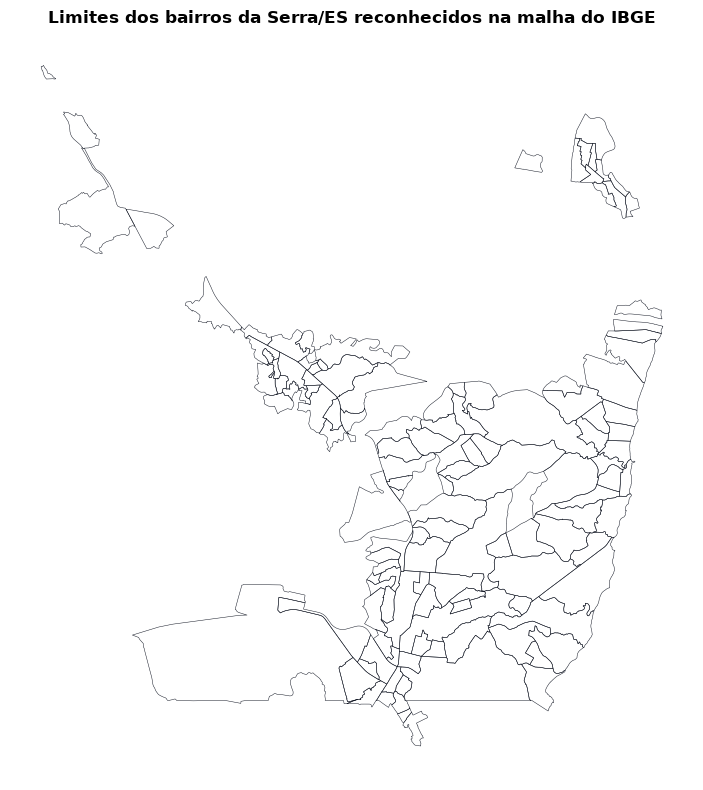

Conferência visual concluída: 130 bairros desenhados a partir da geometria real.
Os indicadores epidemiológicos desta seção estão organizados no nível municipal.


In [188]:
if 'gdf_bairros_serra' not in globals():
    raise RuntimeError('Execute antes a célula de carregamento da malha real de bairros do IBGE.')

fig, ax = plt.subplots(figsize=(8, 8))
gdf_bairros_serra.boundary.plot(ax=ax, color=(0.07, 0.09, 0.14), linewidth=0.35)
ax.set_title('Limites dos bairros da Serra/ES reconhecidos na malha do IBGE', fontsize=12, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f'Conferência visual concluída: {len(gdf_bairros_serra)} bairros desenhados a partir da geometria real.')
print('Os indicadores epidemiológicos desta seção estão organizados no nível municipal.')


---
### Seção 18 - Síntese analítica

Entre 2015 e 2023, a dengue concentrou praticamente todo o volume acumulado de casos municipais na Serra/ES, seguida por chikungunya e zika em proporções bem menores. Esse resultado aparece tanto no total por doença quanto na comparação da média municipal por bairro.

No período analisado, registramos 61.767 casos municipais somando as três arboviroses. Considerando os 130 bairros reconhecidos na malha territorial, a média municipal geral por bairro ficou em aproximadamente 475,1 casos no período. Para dengue, essa média ficou acima de 460 casos, enquanto chikungunya e zika permaneceram abaixo de 10 casos por bairro reconhecido.

A série temporal mostra concentração importante em 2023, ano com maior volume municipal de casos. O mês de março de 2023 apareceu como o ponto mensal mais alto da série, reforçando a presença de períodos críticos concentrados no tempo. A tabela de bairros complementa essa leitura ao organizar a base territorial que sustenta o mapa da Serra/ES.


In [189]:
validacao_mapa_bairros = []
validacao_mapa_bairros.append({
    'checagem': 'df_casos carregado',
    'status': 'OK' if 'df_casos_municipal' in globals() and len(df_casos_municipal) else 'REVISAR',
    'detalhe': f'{len(df_casos_municipal)} registros mensais municipais'
})
validacao_mapa_bairros.append({
    'checagem': 'Fonte dos casos municipais',
    'status': 'OK',
    'detalhe': fonte_casos_municipais
})
validacao_mapa_bairros.append({
    'checagem': 'Período dos casos municipais',
    'status': 'OK',
    'detalhe': f'{periodo_inicio_municipal.date()} a {periodo_fim_municipal.date()}'
})
validacao_mapa_bairros.append({
    'checagem': 'Tabela territorial de bairros',
    'status': 'OK' if 'df_bairros_reconhecidos' in globals() and len(df_bairros_reconhecidos) == 130 else 'REVISAR',
    'detalhe': f'{len(df_bairros_reconhecidos)} bairros com nome, código, distrito e município'
})
validacao_mapa_bairros.append({
    'checagem': 'Filtro municipal Serra/ES',
    'status': 'OK' if gdf_bairros_serra['CD_MUN'].astype(str).eq(CODIGO_MUN_IBGE_SERRA).all() else 'REVISAR',
    'detalhe': f'{len(gdf_bairros_serra)} bairros com CD_MUN == {CODIGO_MUN_IBGE_SERRA}'
})
validacao_mapa_bairros.append({
    'checagem': 'Média municipal por bairro',
    'status': 'OK' if round(media_municipal_geral_por_bairro, 6) == round(total_casos_municipal_geral / total_bairros_reconhecidos, 6) else 'REVISAR',
    'detalhe': f'{total_casos_municipal_geral} casos municipais / {total_bairros_reconhecidos} bairros'
})
validacao_mapa_bairros.append({
    'checagem': 'Resumo por doença',
    'status': 'OK' if len(df_total_doenca_municipal) == 3 else 'REVISAR',
    'detalhe': 'Casos, participação percentual e média municipal por bairro'
})
validacao_mapa_bairros.append({
    'checagem': 'Períodos críticos municipais',
    'status': 'OK' if len(df_anos_criticos_municipais) and len(df_meses_criticos_municipais) else 'REVISAR',
    'detalhe': 'Anos e meses com maior volume municipal de casos'
})

df_validacao_mapa_bairros = pd.DataFrame(validacao_mapa_bairros)
display(df_validacao_mapa_bairros)


,checagem,status,detalhe
0,df_casos carregado,OK,324 registros mensais municipais
1,Fonte dos casos municipais,OK,InfoDengue/Fiocruz - Serra/ES
2,Período dos casos municipais,OK,2015-01-01 a 2023-12-01
3,Tabela territorial de bairros,OK,"130 bairros com nome, código, distrito e munic..."
4,Filtro municipal Serra/ES,OK,130 bairros com CD_MUN == 3205002
5,Média municipal por bairro,OK,61767 casos municipais / 130 bairros
6,Resumo por doença,OK,"Casos, participação percentual e média municip..."
7,Períodos críticos municipais,OK,Anos e meses com maior volume municipal de casos


In [190]:
doenca_maior_total = df_total_doenca_municipal.iloc[0]
ano_maior_total = df_anos_criticos_municipais.iloc[0]
mes_maior_total = df_meses_criticos_municipais.iloc[0]

print('Síntese da parte de Mapa & Bairros')
print(f'Malha real de bairros: {total_bairros_reconhecidos} bairros reconhecidos pelo IBGE.')
print(f'Casos reais municipais: {len(df_casos_municipal)} registros do InfoDengue/Fiocruz.')
print(f'Período municipal analisado: {periodo_inicio_municipal.date()} a {periodo_fim_municipal.date()}.')
print(f'Total municipal no período: {total_casos_municipal_geral} casos.')
print(f'Média municipal por bairro no período: {media_municipal_geral_por_bairro:.1f} casos.')
print(f'Doença com maior acumulado municipal: {doenca_maior_total["doenca"]} ({int(doenca_maior_total["casos"])} casos).')
print(f'Ano com maior volume municipal: {int(ano_maior_total["ano"])} ({int(ano_maior_total["casos"])} casos).')
print(f'Mês com maior volume municipal: {mes_maior_total["periodo"]} ({int(mes_maior_total["casos"])} casos).')
print('A seção combina análise territorial dos bairros e análise temporal municipal das arboviroses.')

print()
print('Diagnóstico final da validação:')
print('[OK] Malha real dos bairros carregada e filtrada para Serra/ES.')
print('[OK] Dados epidemiológicos municipais carregados a partir do InfoDengue/Fiocruz.')
print('[OK] Código municipal, fontes, totais e média municipal por bairro ficaram documentados para auditoria.')
print('[ATENÇÃO] Indicadores epidemiológicos por bairro exigem uma base intramunicipal validada.')


Síntese da parte de Mapa & Bairros
Malha real de bairros: 130 bairros reconhecidos pelo IBGE.
Casos reais municipais: 324 registros do InfoDengue/Fiocruz.
Período municipal analisado: 2015-01-01 a 2023-12-01.
Total municipal no período: 61767 casos.
Média municipal por bairro no período: 475.1 casos.
Doença com maior acumulado municipal: Dengue (60067 casos).
Ano com maior volume municipal: 2023 (26712 casos).
Mês com maior volume municipal: 03/2023 (5760 casos).
A seção combina análise territorial dos bairros e análise temporal municipal das arboviroses.

Diagnóstico final da validação:
[OK] Malha real dos bairros carregada e filtrada para Serra/ES.
[OK] Dados epidemiológicos municipais carregados a partir do InfoDengue/Fiocruz.
[OK] Código municipal, fontes, totais e média municipal por bairro ficaram documentados para auditoria.
[ATENÇÃO] Indicadores epidemiológicos por bairro exigem uma base intramunicipal validada.
